In [16]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

In [17]:
def I_stim(t, a_stim, d_stim, t_stim):
    return sum(
        a_stim_ * (t >= t_stim_) * (t <= t_stim_ + d_stim_) 
        for t_stim_, d_stim_, a_stim_ in zip(t_stim, d_stim, a_stim)
    )

T, dt = 400, 0.005                 # in ms
N = 300                            # number of samples
Nt = int(T / dt) + 1              # number of time steps
df = np.load(f"data/pr_n_data_{N}_T_400_dt_0.005_d_stim_0.88.npz")
sharp_jump_data = np.load(f"data/pr_n_data_{N}_one_sharp.npz")
t_stim, a_stim, d_stim = df['t_stim'], df['a_stim'], df['d_stim']

input_data = np.concatenate([a_stim, d_stim, t_stim], axis=1)  # (N, 3)
output_data = df["v"].squeeze(-1)
sharp_jump_all = sharp_jump_data['sharp_jump'][:, :-1]  # (300, 2)
t = np.arange(0, T + dt, dt).reshape(-1, 1)

train_idx = df['train_idx']
val_idx = df['val_idx']
test_idx = df['test_idx']

I_stim_all = np.stack([I_stim(t.squeeze(-1) , a_stim[i], d_stim[i], t_stim[i]) for i in range(N)],axis=0)  # (N, Nt)
input_data_test, I_stim_all_test, output_data_test, sharp_jump_test = input_data[test_idx], I_stim_all[test_idx], output_data[test_idx], sharp_jump_all[test_idx]

# plotting_impluse_action_potential(t, output_data[0], I_stim(t, a_stim[0], d_stim[0], t_stim[0]), T=T)
print(f" input_data shape: {input_data.shape}, output_data shape: {output_data.shape}, t shape: {t.shape}, sharp_jump shape: {sharp_jump_all.shape}")

 input_data shape: (300, 3), output_data shape: (300, 80001), t shape: (80001, 1), sharp_jump shape: (300, 2)


## Cut-DeepONet

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# 2) Define Cut-DeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=2, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, lifted_trunk_input):
        # branch_input: (B, Nx), lifted_trunk_input: (B, P, 2)
        b = self.branch(branch_input)      # (B, latent)
        # Trunk with lifted domain input
        t = self.trunk(lifted_trunk_input)     # (B, P, latent)
        y = torch.einsum('bl,bpl->bp', b, t) + self.bias  # (B, P)
        return y

cut_deeponet = DeepONet(branch_in=3, latent_dim=128, hidden_dim=256, depth=3).to(device)

# Lifting at the discontinuity locations - check the x sample at the left or right of the discontinuity location at time step t_idx
def H(coorp_np, discon_coords):
    discon_1 = discon_coords[:, 0].astype(np.int64)
    discon_2 = discon_coords[:, 1].astype(np.int64)
    return np.where(coorp_np < coorp_np[discon_1], 0, np.where(coorp_np <= coorp_np[discon_2], 1, 2))

In [19]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[64, 64, 64]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Rebuild and load model weights
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

cutting_net = MLP(input_data.shape[1], sharp_jump_all.shape[1]).to(device)
cutting_net.load_state_dict(checkpoint["model_state_dict"])
cutting_net.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [20]:
def predict_full_field_cut_deeponet(model, t, sample_input, Nt, chunk=20000):
    sample_input = torch.tensor(sample_input[None, :], dtype=torch.float32, device=device)  # (1, Nx)

    pred_sharp_jump = cutting_net(sample_input).detach().numpy()  # (1, Nt)
    sharp_jump_coorp = np.tile(pred_sharp_jump[:2], (Nt, 1))  # (Nt, 2)
    Hx = H(t, sharp_jump_coorp)  # (Nt,)
    pred_lifted_coords_np = np.concatenate([t, Hx], axis=1)  # (Nt, 2)

    preds = []
    with torch.no_grad():
        for i in range(0, pred_lifted_coords_np.shape[0], chunk):
            chunk_lifted_coords = torch.tensor(pred_lifted_coords_np[None, i:i+chunk], dtype=torch.float32, device=device)
            p = model(sample_input, chunk_lifted_coords).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt), pred_sharp_jump

def error_analysis_one_sample(pred, true, t, sharp_jump, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the sharp jump
    left_bound = np.maximum(sharp_jump[0] - window_size, 0)
    right_bound = np.minimum(t.shape[0], sharp_jump[1] + window_size + 1)
    l1_loss_near_sharp = np.mean(abs_err[left_bound:right_bound]) 

    return l1_loss, l1_loss_near_sharp, left_bound, right_bound

def show_results(model, checkpoint, input_data_test, output_data_test, t, sharp_jump_all, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    pred_field, _ = predict_full_field_cut_deeponet(model, t, input_data_test[sample_id], t.shape[0], chunk=20000)
    sample_global_idx = test_idx[sample_id] if "test_idx" in globals() else sample_id
    true_field = output_data_test[sample_id].reshape(-1)

    # _, _, left_bound, right_bound = error_analysis_one_sample(pred_field, true_field, t, sharp_jump_all[sample_id], window_size=int(0.05 * Nt))  # 5% of total points on each side of the discontinuity
    I_stim_sample = I_stim(t, [input_data_test[sample_id, 0]], [input_data_test[sample_id, 1]], [input_data_test[sample_id, 2]]).squeeze()

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
    axes[0].plot(t, I_stim_sample, color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, pred_field, color="red", label="Pred")
    axes[1].plot(t, true_field, color="blue", linestyle="--", label="True")
    # axes[1].axvline(t[left_bound], color="green", linestyle=":", label="Discontinuity region")
    # axes[1].axvline(t[right_bound], color="green", linestyle=":")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(t[:8500], pred_field[:8500], color="red", label="Pred")
    axes[2].plot(t[:8500], true_field[:8500], color="blue", linestyle="--", label="True")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("u")
    axes[2].grid(True)
    axes[2].legend()

    axes[3].plot(train_losses, label="Train")
    axes[3].plot(val_losses, label="Val")
    axes[3].set_yscale("log")
    axes[3].set_xlabel("Epoch")
    axes[3].set_title("Training Curve")
    axes[3].legend()
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

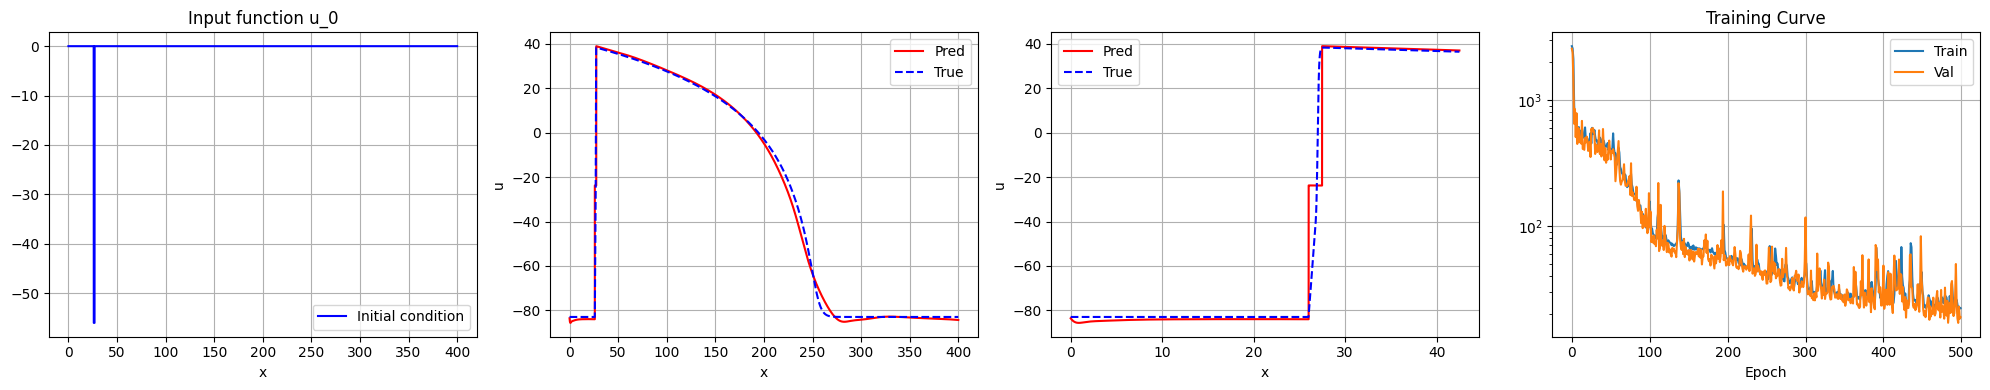

In [21]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
cut_deeponet.load_state_dict(checkpoint["model_state_dict"])
cut_deeponet.eval()

show_results(cut_deeponet, checkpoint, input_data_test, output_data_test, t, sharp_jump_test, sample_id=2)

## DeepONet, flex-DeepOnet, Hyper-DeepONet

In [22]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=1, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        # branch_input: (B, 3), trunk_input: (P, 1)
        b = self.branch(branch_input)      # (B, latent)
        t = self.trunk(trunk_input)        # (P, latent)
        y = b @ t.T + self.bias            # (B, P)
        return y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
deeponet = DeepONet(branch_in=3, latent_dim=128, hidden_dim=450, depth=3).to(device)

In [23]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class BranchNet(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim, depth=3):
        super().__init__()
        self.net = MLP(in_dim, hidden_dim, latent_dim + 1, depth=depth)

    def forward(self, u):
        out = self.net(u)          # (B, latent_dim + 1)
        coeffs = out[:, :-1]       # (B, latent_dim)
        shift = out[:, -1:]        # (B, 1)
        return coeffs, shift

class PreNet(nn.Module):
    def __init__(self, in_dim, hidden_dim, depth=3, use_scale=True):
        super().__init__()
        self.use_scale = use_scale
        out_dim = 2 if use_scale else 1   # [log_s, delta] or just [delta]
        self.net = MLP(in_dim, hidden_dim, out_dim, depth=depth)

    def forward(self, u):
        out = self.net(u)  # (B, out_dim)

        if self.use_scale:
            log_scale = out[:, 0:1]       # (B, 1)
            delta = out[:, 1:2]           # (B, 1)
            scale = torch.exp(log_scale)  # positive scale
        else:
            scale = None
            delta = out[:, 0:1]

        return scale, delta

class TrunkNet(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=256, latent_dim=128, depth=3):
        super().__init__()
        self.net = MLP(in_dim, hidden_dim, latent_dim, depth=depth)

    def forward(self, coords):
        B, P, D = coords.shape
        coords_flat = coords.reshape(B * P, D)
        out = self.net(coords_flat)   # (B*P, latent_dim)
        return out.reshape(B, P, -1)  # (B, P, latent_dim)

class FlexDeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=1, latent_dim=128, hidden_dim=256, depth=3, use_scale=True):
        super().__init__()
        self.branch = BranchNet(branch_in, hidden_dim, latent_dim, depth=depth)
        self.prenet = PreNet(branch_in, hidden_dim, depth=depth, use_scale=use_scale)
        self.trunk = TrunkNet(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def transform_coords(self, trunk_input, scale, delta):
        # trunk_input: (P, 1)
        coords = trunk_input.unsqueeze(0)  # (1, P, 1)
        coords = coords.expand(delta.shape[0], -1, -1)  # (B, P, 1)

        if scale is not None:
            coords = scale.unsqueeze(1) * coords  # (B, P, 1)

        coords = coords + delta.unsqueeze(1)  # (B, P, 1)
        return coords

    def forward(self, branch_input, trunk_input):
        coeffs, out_shift = self.branch(branch_input)    # (B, latent), (B, 1)
        scale, delta = self.prenet(branch_input)         # (B, 1), (B, 1) or None, (B, 1)

        coords_tilde = self.transform_coords(trunk_input, scale, delta)  # (B, P, 1)
        trunk_features = self.trunk(coords_tilde)                         # (B, P, latent)

        y = torch.sum(coeffs.unsqueeze(1) * trunk_features, dim=-1)       # (B, P)
        y = y + out_shift + self.bias
        return y

# ---------------------------
# 3) Instantiate model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flex_deeponet = FlexDeepONet(branch_in=3, trunk_in=1, latent_dim=128, hidden_dim=350, depth=3, use_scale=True).to(device)

In [24]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class HyperNetwork(nn.Module):
    def __init__(self, branch_in, hidden_dim, param_dim, depth=3):
        super().__init__()
        self.net = MLP(branch_in, hidden_dim, param_dim, depth=depth)

    def forward(self, u):
        return self.net(u)   # (B, param_dim)

class TargetNetworkSpec:
    def __init__(self, layer_dims):
        self.layer_dims = layer_dims
        self.shapes = []
        self.param_dim = 0

        for in_dim, out_dim in zip(layer_dims[:-1], layer_dims[1:]):
            w_numel = out_dim * in_dim
            b_numel = out_dim
            self.shapes.append({
                "W_shape": (out_dim, in_dim),
                "b_shape": (out_dim,),
                "W_numel": w_numel,
                "b_numel": b_numel,
            })
            self.param_dim += w_numel + b_numel

    def unflatten(self, flat_params):
        B = flat_params.shape[0]
        params = []
        start = 0

        for spec in self.shapes:
            w_numel = spec["W_numel"]
            b_numel = spec["b_numel"]
            out_dim, in_dim = spec["W_shape"]

            W = flat_params[:, start:start + w_numel].reshape(B, out_dim, in_dim)
            start += w_numel

            b = flat_params[:, start:start + b_numel].reshape(B, out_dim)
            start += b_numel

            params.append((W, b))

        return params

class HyperDeepONet(nn.Module):
    def __init__(self, branch_in, target_layer_dims=(1, 64, 64, 1), hyper_hidden_dim=256, hyper_depth=3, activation=torch.tanh):
        super().__init__()

        self.target_spec = TargetNetworkSpec(list(target_layer_dims))
        self.hypernet = HyperNetwork(branch_in=branch_in, hidden_dim=hyper_hidden_dim, param_dim=self.target_spec.param_dim, depth=hyper_depth)
        self.activation = activation

    def forward(self, branch_input, trunk_input):
        B, P = branch_input.shape[0], trunk_input.shape[0]

        # Generate sample-specific target-network parameters
        flat_params = self.hypernet(branch_input)         # (B, param_dim)
        layer_params = self.target_spec.unflatten(flat_params)

        # Expand coordinates so each sample uses its own generated network
        h = trunk_input.unsqueeze(0).expand(B, P, -1)     # (B, P, 2)

        # Apply target network layer by layer
        num_layers = len(layer_params)
        for i, (W, b) in enumerate(layer_params):
            h = torch.einsum("bpi,boi->bpo", h, W) + b.unsqueeze(1)

            if i < num_layers - 1:
                h = self.activation(h)

        # final h: (B, P, 1)
        return h.squeeze(-1)   # (B, P)

# ---------------------------
# 3) Instantiate model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hyper_deeponet = HyperDeepONet(branch_in=3,target_layer_dims=(1, 64, 64, 1), hyper_hidden_dim=150,hyper_depth=3).to(device)

In [25]:
def predict_full_field(model, sample_input, t, Nt, chunk=20000):
    preds = []
    sample_input = torch.tensor(sample_input[None, :], dtype=torch.float32, device=device)  # (1, Nx)
    with torch.no_grad():
        for i in range(0, t.shape[0], chunk):
            chunk_t = torch.tensor(t[i:i+chunk], dtype=torch.float32, device=device)
            p = model(sample_input, chunk_t).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt)

def error_analysis_one_sample(pred, true, t, sharp_jump, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the sharp jump
    left_bound = np.maximum(sharp_jump[0] - window_size, 0)
    right_bound = np.minimum(t.shape[0], sharp_jump[1] + window_size + 1)
    l1_loss_near_sharp = np.mean(abs_err[left_bound:right_bound]) 

    return l1_loss, l1_loss_near_sharp, left_bound, right_bound

def error_analysis_dataset_test(model, input_data_test, output_data_test, t, sharp_jump_all, window_size=5):
    l1_loss_all, l1_loss_near_discon_all = [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field = predict_full_field(model, input_data_test[sample_id], t, t.shape[0], chunk=20000)

        l1_loss, l1_loss_near_discon, _, _ = error_analysis_one_sample(pred_field, output_data_test[sample_id], t, sharp_jump_all[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, t, sharp_jump_all, sample_id, title=""):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    
    pred_field = predict_full_field(model, input_data_test[sample_id], t, t.shape[0], chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, left_bound, right_bound = error_analysis_one_sample(pred_field, true_field, t, sharp_jump_all[sample_id], window_size=int(0.05 * Nt))  # 5% of total points on each side of the discontinuity
    I_stim_sample = I_stim(t, [input_data_test[sample_id, 0]], [input_data_test[sample_id, 1]], [input_data_test[sample_id, 2]]).squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(t, I_stim_sample, color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, pred_field, color="red", label="Pred")
    axes[1].plot(t, true_field, color="blue", linestyle="--", label="True")
    axes[1].axvline(t[left_bound], color="green", linestyle=":", label="Discontinuity region")
    axes[1].axvline(t[right_bound], color="green", linestyle=":")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.title(title)
    plt.tight_layout()
    plt.show()

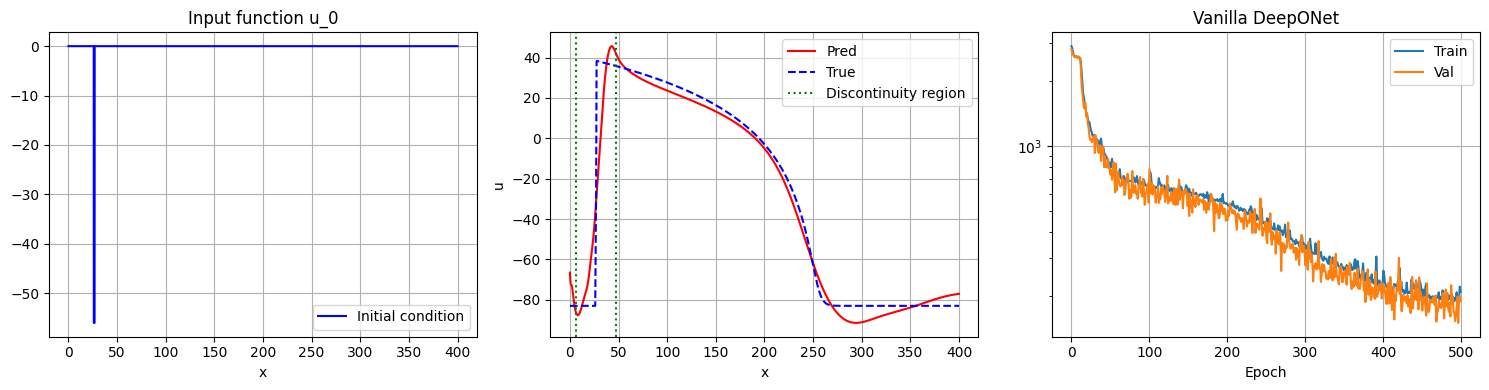

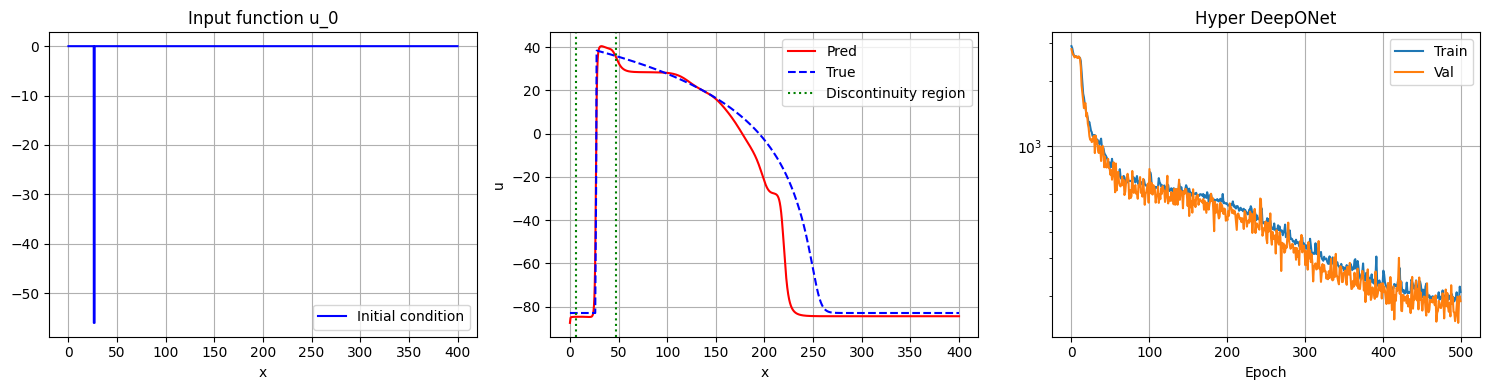

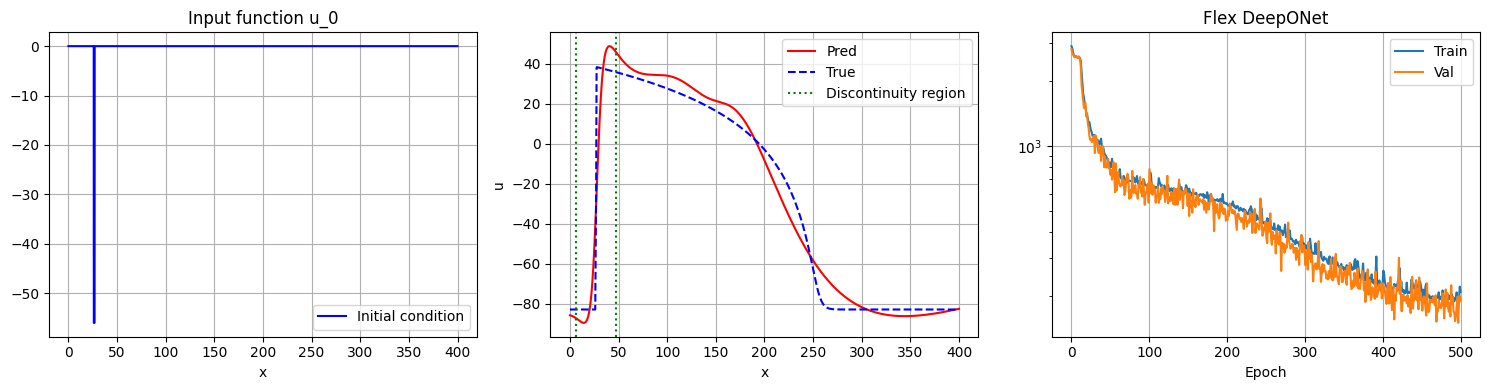

In [26]:
checkpoint = torch.load("checkpoints/hyper_deeponet_checkpoint.pt", map_location=device, weights_only=False)
hyper_deeponet.load_state_dict(checkpoint["model_state_dict"])
hyper_deeponet.eval()

checkpoint = torch.load("checkpoints/vanilla_deeponet_checkpoint.pt", map_location=device, weights_only=False)
deeponet.load_state_dict(checkpoint["model_state_dict"])
deeponet.eval()

checkpoint = torch.load("checkpoints/flex_deeponet_checkpoint.pt", map_location=device, weights_only=False)
flex_deeponet.load_state_dict(checkpoint["model_state_dict"])
flex_deeponet.eval()

show_results(deeponet, checkpoint, input_data_test, output_data_test, t, sharp_jump_test, sample_id=2, title="Vanilla DeepONet")
show_results(hyper_deeponet, checkpoint, input_data_test, output_data_test, t, sharp_jump_test, sample_id=2, title="Hyper DeepONet")
show_results(flex_deeponet, checkpoint, input_data_test, output_data_test, t, sharp_jump_test, sample_id=2, title="Flex DeepONet")

## FNO

In [27]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )

    def compl_mul1d(self, input, weights):
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        b, _, n = x.shape
        x_ft = torch.fft.rfft(x)
        out_ft = torch.zeros(b, self.out_channels, x_ft.size(-1), dtype=torch.cfloat, device=x.device)

        m = min(self.modes, x_ft.size(-1))
        out_ft[:, :, :m] = self.compl_mul1d(x_ft[:, :, :m], self.weights[:, :, :m])

        return torch.fft.irfft(out_ft, n=n)


class FNO1d(nn.Module):
    def __init__(self, in_channels=2, width=64, modes=16):
        super().__init__()
        self.fc0 = nn.Linear(in_channels, width)

        self.conv0 = SpectralConv1d(width, width, modes)
        self.conv1 = SpectralConv1d(width, width, modes)
        self.conv2 = SpectralConv1d(width, width, modes)
        self.conv3 = SpectralConv1d(width, width, modes)

        self.w0 = nn.Conv1d(width, width, 1)
        self.w1 = nn.Conv1d(width, width, 1)
        self.w2 = nn.Conv1d(width, width, 1)
        self.w3 = nn.Conv1d(width, width, 1)

        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # x: (B, 2, nt_sub)
        x = x.permute(0, 2, 1)          # (B, nt_sub, 2)
        x = self.fc0(x)                 # (B, nt_sub, width)
        x = x.permute(0, 2, 1)          # (B, width, nt_sub)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        x = x.permute(0, 2, 1)          # (B, nt_sub, width)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)                 # (B, nt_sub, 1)
        return x.permute(0, 2, 1)       # (B, 1, nt_sub)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fno = FNO1d(in_channels=2, width=80, modes=16).to(device)

In [28]:
def predict_full_field_fno(model, sample_input, t_domain):
    # Build FNO input for one sample: [u0(x), t] -> (1, 2, Nt)
    t_vec = t_domain.squeeze().astype(np.float32)  # (Nt,)
    t_grid = np.broadcast_to(t_vec[None, :], I_stim_all_test.shape)                        # (1, Nt)
    X_in = np.stack([sample_input, t_vec], axis=0)[None, :, :].astype(np.float32)

    # Predict
    with torch.no_grad():
        X_in = torch.from_numpy(X_in).to(device)
        pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()  

    return pred_field

def error_analysis_all_t(pred, true, t, sharp_jump, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the sharp jump
    left_bound = np.maximum(sharp_jump[0] - window_size, 0)
    right_bound = np.minimum(t.shape[0], sharp_jump[1] + window_size + 1)
    l1_loss_near_sharp = np.mean(abs_err[left_bound:right_bound]) 

    return l1_loss, l1_loss_near_sharp, left_bound, right_bound

def show_results(model, checkpoint, I_stim_all_test, output_data_test, t_domain, sharp_jump_all, sample_id):
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    # Pick one validation sample (original dataset index)
    X_sample, Y_sample = I_stim_all_test[sample_id, :].astype(np.float32), output_data_test[sample_id, :].astype(np.float32)

    pred_field = predict_full_field_fno(model, X_sample, t_domain)

    # Error analysis
    _, _, left_bound, right_bound = error_analysis_all_t(pred_field, Y_sample, t, sharp_jump_all[sample_id], window_size=int(0.05 * Nt))  # 5% of total points on each side of the discontinuity

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(t, I_stim_all_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, pred_field, color="red", label="Pred")
    axes[1].plot(t, Y_sample, color="blue", linestyle="--", label="True")
    axes[1].axvline(t[left_bound], color="green", linestyle=":", label="Discontinuity region")
    axes[1].axvline(t[right_bound], color="green", linestyle=":")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)


    plt.tight_layout()
    plt.show()

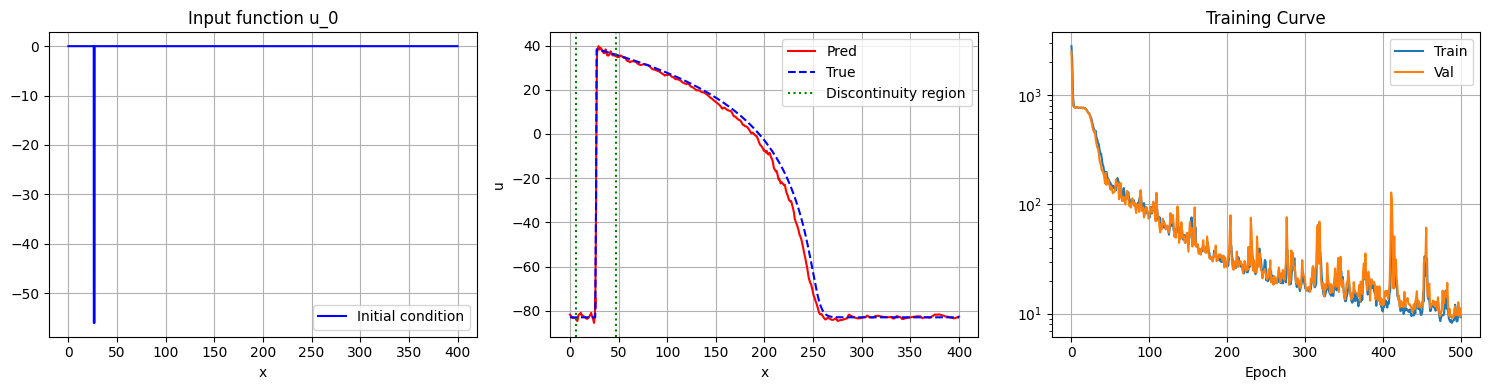

In [29]:
# Load the trained Vanilla-FNO checkpoint
checkpoint = torch.load(f"checkpoints/vanilla_fno_checkpoint.pt", map_location=device, weights_only=False)
fno.load_state_dict(checkpoint["model_state_dict"])
fno.eval()

show_results(fno, checkpoint, I_stim_all_test, output_data_test, t, sharp_jump_test, sample_id=2)

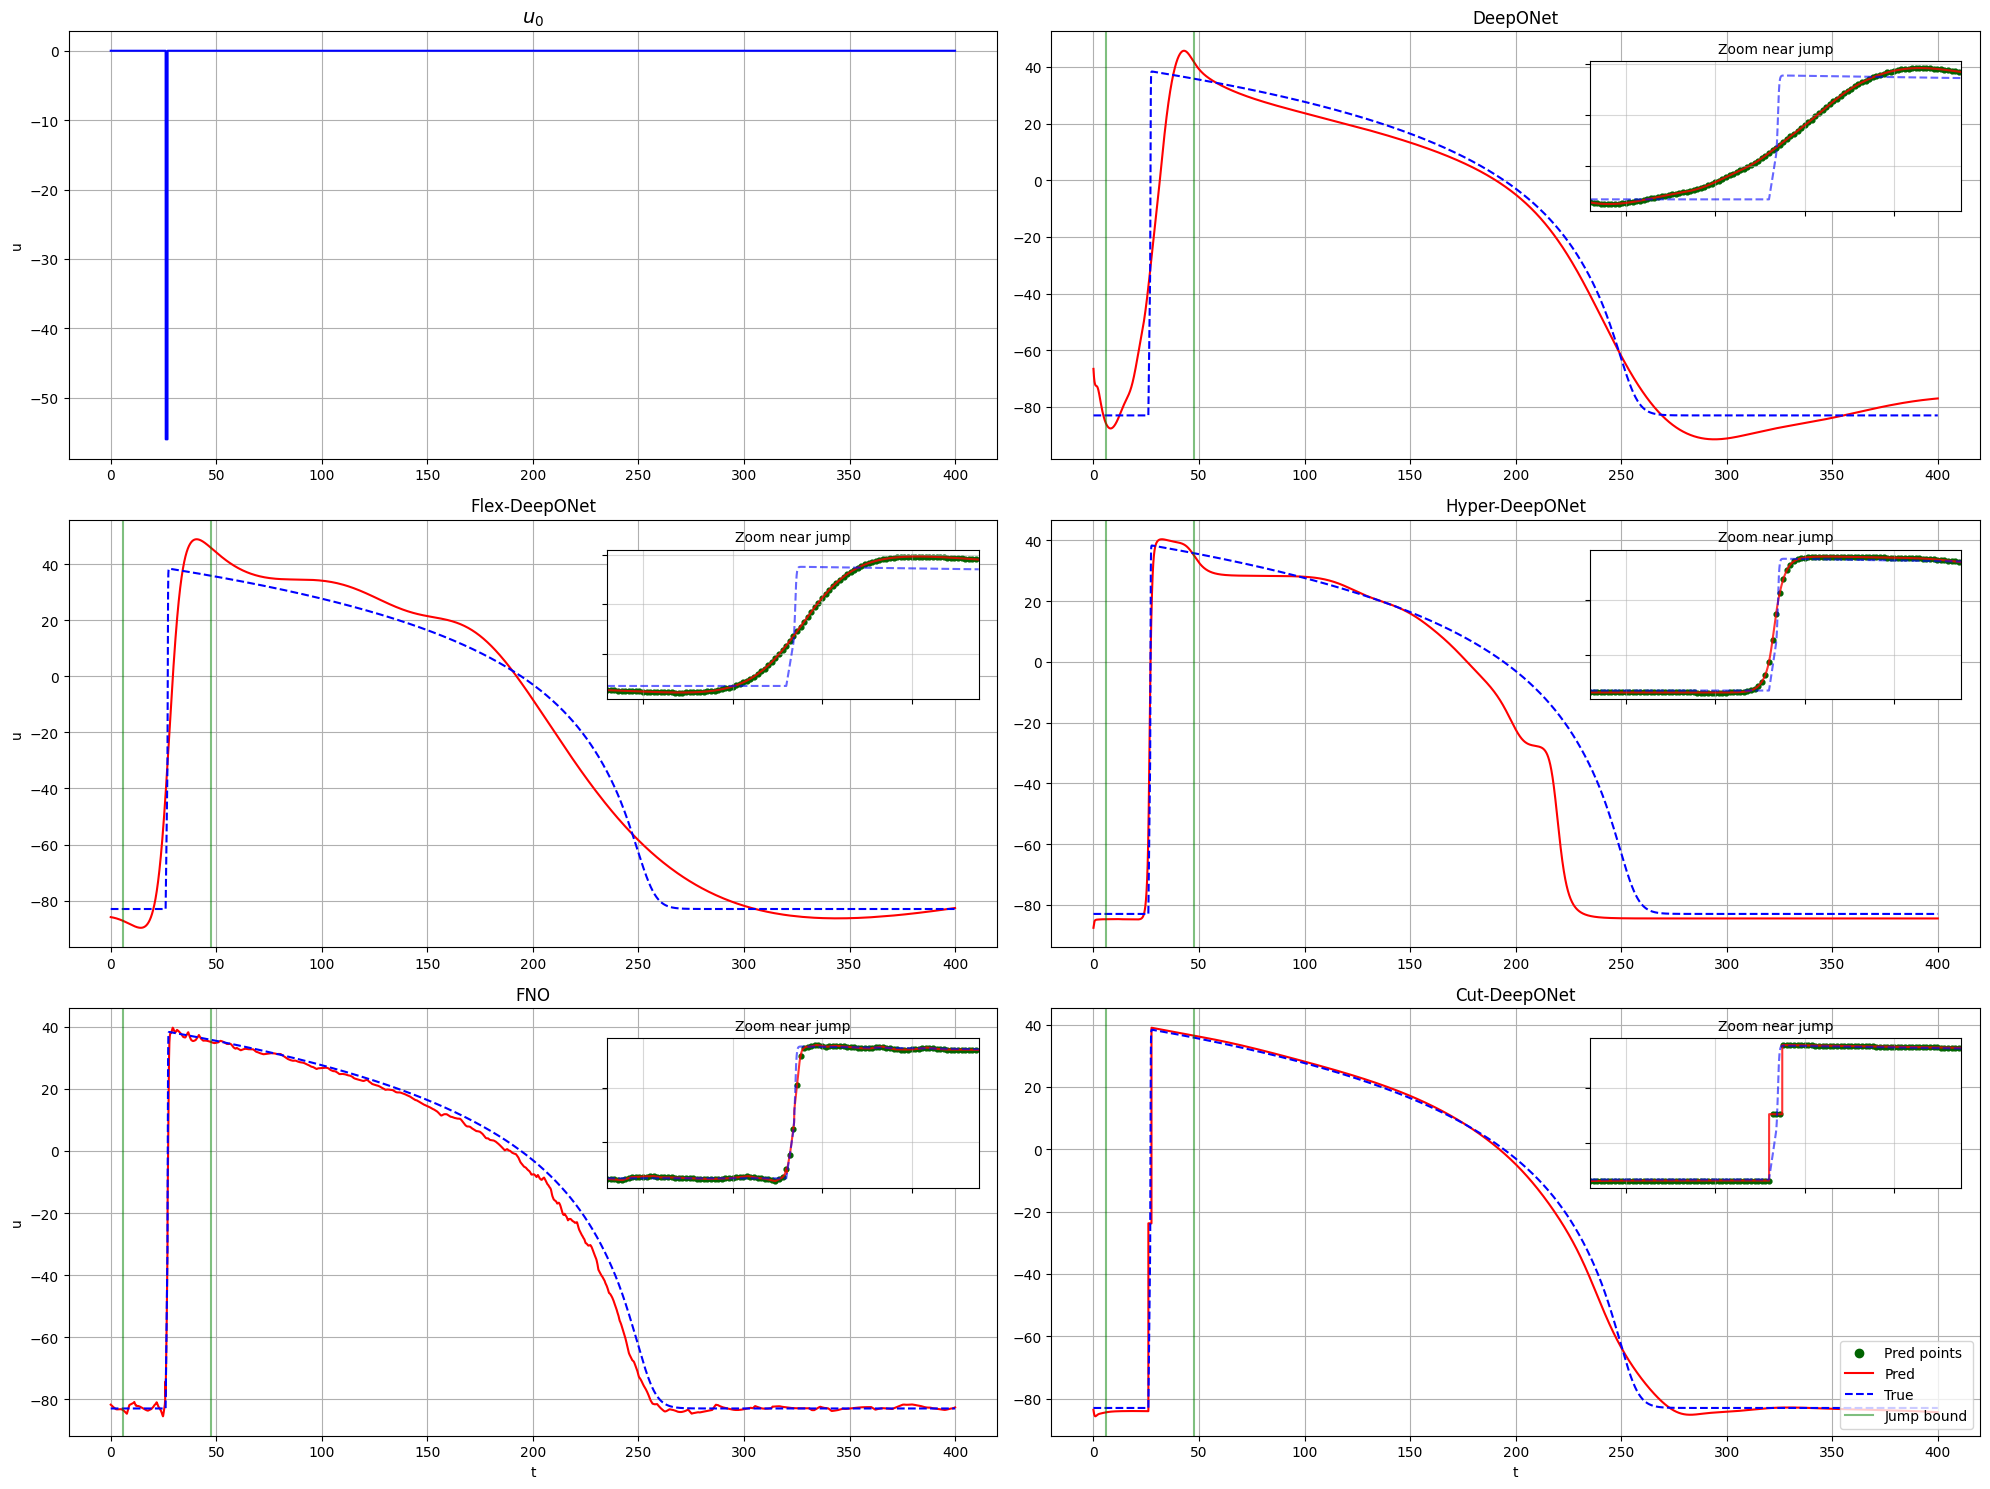

In [31]:
def plotting_all_in_one(
    deeponet, flex_deeponet, hyper_deeponet, fno,
    input_data_test, output_data_test, t_domain_test, sharp_jump_all,
    sample_id, t_plot=0.07
):
    checkpoint_deeponet = torch.load("checkpoints/vanilla_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_flex = torch.load("checkpoints/flex_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_hyper = torch.load("checkpoints/hyper_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_cut = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_fno = torch.load("checkpoints/vanilla_fno_checkpoint.pt", map_location=device, weights_only=False)

    deeponet.load_state_dict(checkpoint_deeponet["model_state_dict"])
    flex_deeponet.load_state_dict(checkpoint_flex["model_state_dict"])
    hyper_deeponet.load_state_dict(checkpoint_hyper["model_state_dict"])
    cut_deeponet.load_state_dict(checkpoint_cut["model_state_dict"])
    fno.load_state_dict(checkpoint_fno["model_state_dict"])

    deeponet.eval()
    flex_deeponet.eval()
    hyper_deeponet.eval()
    cut_deeponet.eval()
    fno.eval()

    Nt = t_domain_test.shape[0]
    pred_deeponet = predict_full_field(deeponet, input_data_test[sample_id], t, Nt)
    pred_flex = predict_full_field(flex_deeponet, input_data_test[sample_id], t, Nt)
    pred_hyper = predict_full_field(hyper_deeponet, input_data_test[sample_id], t, Nt)
    pred_cut, _ = predict_full_field_cut_deeponet(cut_deeponet, t, input_data_test[sample_id], Nt)
    pred_fno = predict_full_field_fno(fno, I_stim_all_test[sample_id], t)

    true_field = output_data_test[sample_id]

    window_size = int(0.05 * t.shape[0])
    left_bound = max(0, sharp_jump_all[sample_id][0] - window_size)
    right_bound = min(t.shape[0], sharp_jump_all[sample_id][1] + window_size)

    fig, axes = plt.subplots(3, 2, figsize=(20, 15))
    axes = axes.ravel()

    axes[0].plot(t, I_stim_all_test[sample_id], color="blue")
    axes[0].set_title(r"$u_0$", fontsize=14)
    # axes[0].set_xlabel("t")
    axes[0].set_ylabel("u")
    axes[0].grid(True)

    model_plots = [
        ("DeepONet", pred_deeponet),
        ("Flex-DeepONet", pred_flex),
        ("Hyper-DeepONet", pred_hyper),
        ("FNO", pred_fno),
        ("Cut-DeepONet", pred_cut),
    ]

    for i, (name, pred) in enumerate(model_plots, start=1):
        axes[i].plot([], [], color="darkgreen", marker='o', linestyle='None', markersize=6, label="Pred points")
        axes[i].plot(t, pred, color="red", label="Pred")
        axes[i].plot(t, true_field, color="blue", linestyle="--", label="True")
        axes[i].axvline(t[left_bound], color="green", alpha=0.5, label="Jump bound")
        axes[i].axvline(t[right_bound], color="green", alpha=0.5)
        axins = axes[i].inset_axes([0.58, 0.58, 0.4, 0.35])

        x_zoom = t[left_bound:right_bound + 1].squeeze()
        axins.scatter(x_zoom[::80], pred[left_bound:right_bound + 1:80], color="darkgreen", label="Pred points", s=12)
        axins.plot(x_zoom, pred[left_bound:right_bound + 1], color="red", alpha=0.8)
        axins.plot(x_zoom, true_field[left_bound:right_bound + 1], color="blue", linestyle="--", alpha=0.6)
        axins.set_xlim(x_zoom[0], x_zoom[-1])
        axins.set_title("Zoom near jump", fontsize=10)
        axins.tick_params(axis="x", labelbottom=False)
        axins.tick_params(axis="y", labelleft=False)
        axins.grid(True, alpha=0.5)

        axes[i].set_title(f"{name}")
        axes[i].grid(True)
        if i % 2 == 0:
            axes[i].set_ylabel("u")
        if i == 4 or i == 5:
            axes[i].set_xlabel("t")
        if i == 5:
            axes[i].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig("pasimonious_model_comparison.png", dpi=300)
    plt.show()


plotting_all_in_one(
    deeponet, flex_deeponet, hyper_deeponet, fno,
    input_data_test, output_data_test, t, sharp_jump_test,
    sample_id=2
)